In [129]:
from typing import Callable
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import random
import time

In [130]:
def threesum(target: int, arr: list[int]) -> tuple[bool, int]:
    """
    Write a complete implementation of the brute force ThreeSum algorithm that:

    Uses three nested loops to check all possible triplets
    Ensures indices i, j, k are distinct
    Returns true/false OR returns the actual triplet (your choice, document it)
    Handles edge cases properly (array too small, null input, etc.)
    
    Requirements:
    - Include comprehensive comments explaining your approach
    - Add a counter variable to track the number of basic operations performed
    - Implement input validation
    - Provide at least 5 test cases with expected outputs
    
    Parameters:
    - :target: comparer 
    - :arr: Array of integers
    
    Returns:
    - A tuple which contains: whether a match was found, and the count of basic operations performed
    """
    # input validation
    n = len(arr)

    if n <= 2:
        raise ValueError(f"Array has to have at least 3 elements or more. Current length: {n}")
    
    # --- main operation ---
    count = 0 # count of basic operations
    
    for i in range(n - 2):
        for j in range(i + 1, n):
            for k in range(j + 1, n):
                # increase count by one
                count += 1
                
                # add current integers together
                res = arr[i] + arr[j] + arr[k]
                
                # compare result with target
                if res == target:
                    return (True, count,)
    return (False, count,)

# Test Cases

## Test Case 1

In [131]:
target = 6
arr = [1, 2, 3, 4]

# Expected output: (True, 1)

In [132]:
result1 = threesum(target, arr)

In [133]:
print("Test 1 Results:\n\n", f"Match found: {result1[0]}\n", f"Count of Operations: {result1[1]}")

Test 1 Results:

 Match found: True
 Count of Operations: 1


## Test Case 2

In [134]:
target = 50
arr = [5, 10, 15, 20]

# Expected output: (False, 4)

In [135]:
result2 = threesum(target, arr)

In [136]:
print("Test 2 Results:\n\n", f"Match found: {result2[0]}\n", f"Count of Operations: {result2[1]}")

Test 2 Results:

 Match found: False
 Count of Operations: 4


## Test Case 3

In [137]:
target = 10
arr = [1, 2]

# Expected Output: raise array length ValueError

In [138]:
try:
    result3 = threesum(target, arr)
except ValueError as err:
    if str(err) == "Array has to have at least 3 elements or more. Current length: 2":
        result3 = True # did raise error as expected
else:
    result3 = False # did not raise error as expected

In [139]:
print("Test 3 Results:\n\n", f"Raised array length ValueError: {result3}")

Test 3 Results:

 Raised array length ValueError: True


## Test Case 4

In [140]:
target = 0
arr = [-5, 2, 3, 0]

# Expected Output: (True, 1)

In [141]:
result4 = threesum(target, arr)

In [142]:
print("Test 4 Results:\n\n", f"Match found: {result4[0]}\n", f"Count of Operations: {result4[1]}")

Test 4 Results:

 Match found: True
 Count of Operations: 1


## Test Case 5

In [143]:
target = 10
arr = [2, 3, 5, 7, -1, 8]

# Expected Output: (True, 1)

In [144]:
result5 = threesum(target, arr)

In [145]:
print("Test 5 Results:\n\n", f"Match found: {result5[0]}\n", f"Count of Operations: {result5[1]}")

Test 5 Results:

 Match found: True
 Count of Operations: 1


In [146]:
def generate_test_array(size: int) -> tuple[list[int], int]:
    random.seed(42)

    arr = [0] * size
    for i in range(size): arr[i] = random.randint(-100, 100)
    
    test_target = random.choice(arr) + random.choice(arr) + random.choice(arr)

    return arr, test_target

def time_algorithm(algo: Callable[[int, list[int]], tuple[bool, int]], arr: list[int], target: int) -> tuple[float, int]:
    print("----------------------------------")
    print("Testing Algorithm:", algo.__name__)
    print("Array Size:", len(arr))

    start = time.perf_counter()
    _, operations = algo(target, arr.copy())


    print("Time:", time.perf_counter() - start, "seconds")
    print("----------------------------------")

    return time.perf_counter() - start, operations

# Empirical Performance Testing
We will do 5 trials in which per trial, we will run the algorithm on a randomly generated array of 5 different sizes. We will time the runtime and run the algorithm ten times before collecting the averages of those runs

In [147]:
times_arr = []
ops_arr = []
tmp_time = []
tmp_op = 0
array_sizes = [50, 100, 200, 400, 800]

## Trial 1

In [148]:
test_array, test_target = generate_test_array(array_sizes[0])

for i in range(10):
    rt, ops = time_algorithm(threesum, test_array, test_target)
    tmp_op += ops
    tmp_time.append(rt)
    
times_arr.append(np.average(tmp_time))
ops_arr.append(tmp_op / 10)

tmp_op = 0
tmp_time.clear()

----------------------------------
Testing Algorithm: threesum
Array Size: 50
Time: 3.92910442315042e-05 seconds
----------------------------------
----------------------------------
Testing Algorithm: threesum
Array Size: 50
Time: 3.487500362098217e-05 seconds
----------------------------------
----------------------------------
Testing Algorithm: threesum
Array Size: 50
Time: 3.383401781320572e-05 seconds
----------------------------------
----------------------------------
Testing Algorithm: threesum
Array Size: 50
Time: 3.3374992199242115e-05 seconds
----------------------------------
----------------------------------
Testing Algorithm: threesum
Array Size: 50
Time: 3.291695611551404e-05 seconds
----------------------------------
----------------------------------
Testing Algorithm: threesum
Array Size: 50
Time: 3.2957992516458035e-05 seconds
----------------------------------
----------------------------------
Testing Algorithm: threesum
Array Size: 50
Time: 3.241701051592827e-05

## Trial 2

In [149]:
test_array, test_target = generate_test_array(array_sizes[1])

for i in range(10):
    rt, ops = time_algorithm(threesum, test_array, test_target)
    
    tmp_op += ops
    tmp_time.append(rt)
    
times_arr.append(np.average(tmp_time))
ops_arr.append(tmp_op / 10)

tmp_op = 0
tmp_time.clear()
    

----------------------------------
Testing Algorithm: threesum
Array Size: 100
Time: 3.125000512227416e-05 seconds
----------------------------------
----------------------------------
Testing Algorithm: threesum
Array Size: 100
Time: 2.8582988306879997e-05 seconds
----------------------------------
----------------------------------
Testing Algorithm: threesum
Array Size: 100
Time: 2.7250032871961594e-05 seconds
----------------------------------
----------------------------------
Testing Algorithm: threesum
Array Size: 100
Time: 2.7375004719942808e-05 seconds
----------------------------------
----------------------------------
Testing Algorithm: threesum
Array Size: 100
Time: 2.7332978788763285e-05 seconds
----------------------------------
----------------------------------
Testing Algorithm: threesum
Array Size: 100
Time: 2.7084024623036385e-05 seconds
----------------------------------
----------------------------------
Testing Algorithm: threesum
Array Size: 100
Time: 2.71250028

## Trial 3

In [150]:
test_array, test_target = generate_test_array(array_sizes[2])

for i in range(10):
    rt, ops = time_algorithm(threesum, test_array, test_target)
    
    tmp_op += ops
    tmp_time.append(rt)
    
times_arr.append(np.average(tmp_time))
ops_arr.append(tmp_op / 10)

tmp_op = 0
tmp_time.clear()

----------------------------------
Testing Algorithm: threesum
Array Size: 200
Time: 4.63749747723341e-05 seconds
----------------------------------
----------------------------------
Testing Algorithm: threesum
Array Size: 200
Time: 4.3208012357354164e-05 seconds
----------------------------------
----------------------------------
Testing Algorithm: threesum
Array Size: 200
Time: 4.237500252202153e-05 seconds
----------------------------------
----------------------------------
Testing Algorithm: threesum
Array Size: 200
Time: 4.2082974687218666e-05 seconds
----------------------------------
----------------------------------
Testing Algorithm: threesum
Array Size: 200
Time: 4.2499974370002747e-05 seconds
----------------------------------
----------------------------------
Testing Algorithm: threesum
Array Size: 200
Time: 4.175002686679363e-05 seconds
----------------------------------
----------------------------------
Testing Algorithm: threesum
Array Size: 200
Time: 4.18340205214

## Trial 4

In [151]:
test_array, test_target = generate_test_array(array_sizes[3])

for i in range(10):
    rt, ops = time_algorithm(threesum, test_array, test_target)
    
    tmp_op += ops
    tmp_time.append(rt)
    
times_arr.append(np.average(tmp_time))
ops_arr.append(tmp_op / 10)

tmp_op = 0
tmp_time.clear()

----------------------------------
Testing Algorithm: threesum
Array Size: 400
Time: 1.47090177051723e-05 seconds
----------------------------------
----------------------------------
Testing Algorithm: threesum
Array Size: 400
Time: 1.0000017937272787e-05 seconds
----------------------------------
----------------------------------
Testing Algorithm: threesum
Array Size: 400
Time: 8.708040695637465e-06 seconds
----------------------------------
----------------------------------
Testing Algorithm: threesum
Array Size: 400
Time: 8.29098280519247e-06 seconds
----------------------------------
----------------------------------
Testing Algorithm: threesum
Array Size: 400
Time: 8.083006832748652e-06 seconds
----------------------------------
----------------------------------
Testing Algorithm: threesum
Array Size: 400
Time: 7.916998583823442e-06 seconds
----------------------------------
----------------------------------
Testing Algorithm: threesum
Array Size: 400
Time: 8.00000270828604

## Trial 5

In [152]:
test_array, test_target = generate_test_array(array_sizes[4])

for i in range(10):
    rt, ops = time_algorithm(threesum, test_array, test_target)
    
    tmp_op += ops
    tmp_time.append(rt)
    
times_arr.append(np.average(tmp_time))
ops_arr.append(tmp_op / 10)

tmp_op = 0
tmp_time.clear()

----------------------------------
Testing Algorithm: threesum
Array Size: 800
Time: 1.4417048078030348e-05 seconds
----------------------------------
----------------------------------
Testing Algorithm: threesum
Array Size: 800
Time: 8.707982487976551e-06 seconds
----------------------------------
----------------------------------
Testing Algorithm: threesum
Array Size: 800
Time: 5.999987479299307e-06 seconds
----------------------------------
----------------------------------
Testing Algorithm: threesum
Array Size: 800
Time: 5.499983672052622e-06 seconds
----------------------------------
----------------------------------
Testing Algorithm: threesum
Array Size: 800
Time: 5.084031727164984e-06 seconds
----------------------------------
----------------------------------
Testing Algorithm: threesum
Array Size: 800
Time: 4.833040293306112e-06 seconds
----------------------------------
----------------------------------
Testing Algorithm: threesum
Array Size: 800
Time: 4.749977961182

# Results

In [153]:
df = pd.DataFrame({
    "Array Sizes": array_sizes,
    "Runtimes": times_arr,
    "Operation Count": ops_arr
})

df

,Array Sizes,Runtimes,Operation Count
0,50,0.000052,419.0
1,100,0.000046,345.0
2,200,0.000061,509.0
3,400,0.000027,84.0
4,800,0.000025,37.0


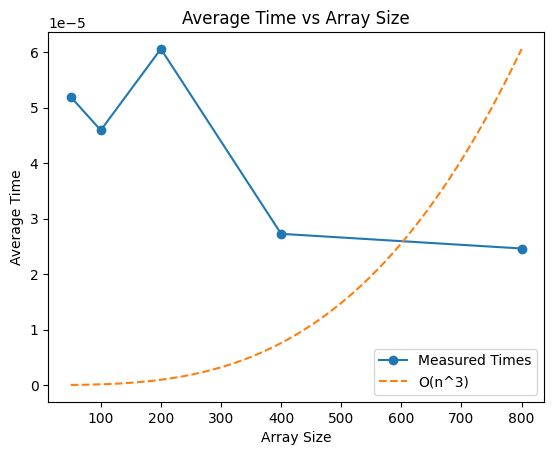

In [154]:
plt.figure()
plt.plot(array_sizes, times_arr, marker='o', label="Measured Times")

x_smooth = np.linspace(min(array_sizes), max(array_sizes), 500)
scale = max(times_arr) / max(np.array(array_sizes) ** 3)
y_smooth = scale * (x_smooth**3)
plt.plot(x_smooth, y_smooth, label="O(n^3)", linestyle="--")

plt.xlabel("Array Size")
plt.ylabel("Average Time")
plt.title("Average Time vs Array Size")
plt.legend()
plt.show()

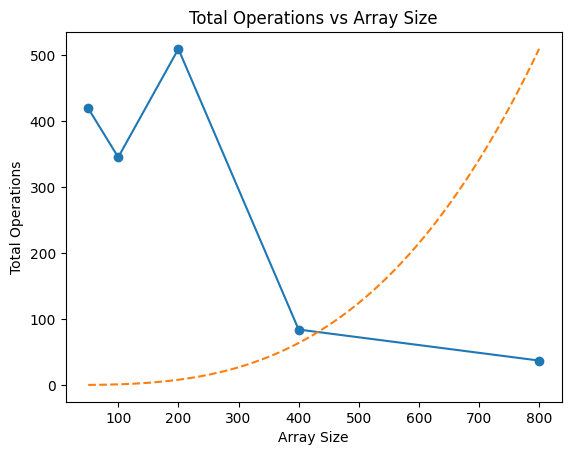

In [155]:
plt.figure()
plt.plot(array_sizes, ops_arr, marker = 'o')

x_smooth = np.linspace(min(array_sizes), max(array_sizes), 500)
scale = max(ops_arr) / max(np.array(array_sizes) ** 3)
y_smooth = scale * (x_smooth**3)
plt.plot(x_smooth, y_smooth, label="O(n^3)", linestyle="--")

plt.xlabel("Array Size")
plt.ylabel("Total Operations")
plt.title("Total Operations vs Array Size")
plt.show()

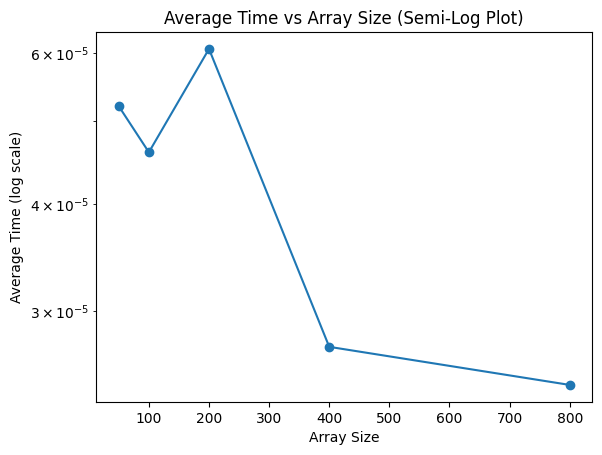

In [156]:
plt.figure()
plt.semilogy(array_sizes, times_arr, marker = 'o')
plt.xlabel("Array Size")
plt.ylabel("Average Time (log scale)")
plt.title("Average Time vs Array Size (Semi-Log Plot)")
plt.show()